In [ ]:
!pip install xgboost lightgbm shap optuna --quiet
print("✓ All libraries ready")

✓ All libraries ready



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# What: loads all Python libraries into memory
# Why: we need pandas for data, numpy for math,
#      sklearn for metrics, xgboost/lightgbm for models
# Expected output: version numbers printed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import optuna
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    classification_report, confusion_matrix, roc_curve
)

print(f"pandas  : {pd.__version__}")
print(f"xgboost : {__import__('xgboost').__version__}")
print(f"lightgbm: {__import__('lightgbm').__version__}")
print(f"shap    : {shap.__version__}")
print(f"optuna  : {optuna.__version__}")
print("✓ All imports done")

pandas  : 2.0.3
xgboost : 1.7.6
lightgbm: 4.6.0
shap    : 0.49.1
optuna  : 4.8.0
✓ All imports done


In [3]:
# What: loads the fixed train/test data and the feature importance file
# Why: train = what the model learns from (144,415 rows)
#      test  = what we evaluate on (36,104 rows) - NEVER used during training
#      feature_importance = tells us which features to keep
# Expected output: shapes printed for all 3 files

train_df   = pd.read_csv("dataco_train_FIXED.csv")
test_df    = pd.read_csv("dataco_test_FIXED.csv")
feat_imp   = pd.read_csv("feature_importance.csv")

print(f"Train shape : {train_df.shape}")
print(f"Test  shape : {test_df.shape}")
print(f"\nTop 10 features from AutoML:")
print(feat_imp[["variable","percentage"]].head(10).to_string(index=False))

Train shape : (144415, 46)
Test  shape : (36104, 46)

Top 10 features from AutoML:
     variable  percentage
    delay_gap    0.687106
   is_delayed    0.253956
Type_TRANSFER    0.009297
   Order City    0.004703
    order_day    0.004285
  delay_ratio    0.004081
  Order State    0.003635
Customer City    0.003024
Order Country    0.002601
 Order Region    0.002396


In [4]:
# What: picks the 10 most important features from AutoML's ranking
# Why: delay_gap alone = 68.7% of decisions, is_delayed = 25.4%
#      the top 10 together cover 96%+ of the model's logic
#      training on all 45 features adds noise with almost no benefit
#      fewer features = faster training, less overfitting
# Expected output: list of 10 feature names

TARGET = "Late_delivery_risk"

# Take top 10 features by importance
TOP_N = 10
top_features = feat_imp["variable"].head(TOP_N).tolist()

print(f"Top {TOP_N} features selected:")
for i, f in enumerate(top_features, 1):
    pct = feat_imp.loc[feat_imp["variable"]==f, "percentage"].values[0] * 100
    print(f"  {i:02d}. {f:45s}  {pct:.2f}%")

# Create X (features) and y (target) for train and test
X_train = train_df[top_features]
y_train = train_df[TARGET]
X_test  = test_df[top_features]
y_test  = test_df[TARGET]

print(f"\nX_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"\nTarget balance (train):")
print(y_train.value_counts(normalize=True).round(3))

Top 10 features selected:
  01. delay_gap                                      68.71%
  02. is_delayed                                     25.40%
  03. Type_TRANSFER                                  0.93%
  04. Order City                                     0.47%
  05. order_day                                      0.43%
  06. delay_ratio                                    0.41%
  07. Order State                                    0.36%
  08. Customer City                                  0.30%
  09. Order Country                                  0.26%
  10. Order Region                                   0.24%

X_train: (144415, 10)
X_test : (36104, 10)

Target balance (train):
Late_delivery_risk
1    0.549
0    0.451
Name: proportion, dtype: float64


In [5]:
# What: trains XGBoost with default settings, no tuning at all
# Why: always start with a baseline first
#      this tells you the FLOOR - the minimum your model can do
#      if defaults already hit 0.99 AUC, your features are doing the work
#      if defaults hit only 0.85, you know tuning is very important
# Expected output: AUC around 0.98-0.99, accuracy around 96-98%

xgb_base = XGBClassifier(
    n_estimators  = 100,
    random_state  = 42,
    eval_metric   = "logloss",
    use_label_encoder = False,
    verbosity     = 0
)

xgb_base.fit(X_train, y_train)

# Evaluate
y_pred_xgb  = xgb_base.predict(X_test)
y_prob_xgb  = xgb_base.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("=" * 45)
print("XGBoost Baseline (default settings)")
print("=" * 45)
print(f"  AUC-ROC  : {auc_xgb:.4f}  (AutoML = 0.9926)")
print(f"  F1 Score : {f1_xgb:.4f}")
print(f"  Accuracy : {acc_xgb*100:.2f}%")
print(f"\n  Gap to AutoML: {0.9926 - auc_xgb:+.4f}")

XGBoost Baseline (default settings)
  AUC-ROC  : 0.9920  (AutoML = 0.9926)
  F1 Score : 0.9724
  Accuracy : 96.92%

  Gap to AutoML: +0.0006


In [6]:
# What: trains LightGBM with default settings on the same features
# Why: LightGBM is faster and often scores slightly differently
#      we compare both baselines and tune only the WINNER
#      this takes less than 1 minute to run
# Expected output: AUC similar to XGBoost - compare both

lgbm_base = LGBMClassifier(
    n_estimators = 100,
    random_state = 42,
    verbosity    = -1
)

lgbm_base.fit(X_train, y_train)

y_pred_lgbm = lgbm_base.predict(X_test)
y_prob_lgbm = lgbm_base.predict_proba(X_test)[:, 1]

auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)
f1_lgbm  = f1_score(y_test, y_pred_lgbm)
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)

print("=" * 45)
print("LightGBM Baseline (default settings)")
print("=" * 45)
print(f"  AUC-ROC  : {auc_lgbm:.4f}  (AutoML = 0.9926)")
print(f"  F1 Score : {f1_lgbm:.4f}")
print(f"  Accuracy : {acc_lgbm*100:.2f}%")
print(f"\n  Gap to AutoML: {0.9926 - auc_lgbm:+.4f}")

print("\n" + "=" * 45)
print("BASELINE COMPARISON")
print("=" * 45)
winner = "XGBoost" if auc_xgb >= auc_lgbm else "LightGBM"
print(f"  XGBoost  AUC: {auc_xgb:.4f}")
print(f"  LightGBM AUC: {auc_lgbm:.4f}")
print(f"  → Tuning winner: {winner}")

LightGBM Baseline (default settings)
  AUC-ROC  : 0.9921  (AutoML = 0.9926)
  F1 Score : 0.9748
  Accuracy : 97.17%

  Gap to AutoML: +0.0005

BASELINE COMPARISON
  XGBoost  AUC: 0.9920
  LightGBM AUC: 0.9921
  → Tuning winner: LightGBM


In [7]:
# What: runs 50 experiments, each trying different settings
#       Optuna learns from each trial what to try next (Bayesian search)
# Why: the default settings are good but not optimal
#      Optuna searches: tree depth, learning rate, samples per tree,
#      feature fraction, regularization - 5 dimensions at once
#      manually trying these combinations would take days
#      Optuna does it in ~15 minutes automatically
# Expected output: "Trial N finished with AUC X" then best params

def objective(trial):
    # Optuna suggests a value in each range for this trial
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 100, 500),
        "max_depth"         : trial.suggest_int("max_depth", 3, 9),
        "learning_rate"     : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample"         : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree"  : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight"  : trial.suggest_int("min_child_weight", 1, 10),
        "gamma"             : trial.suggest_float("gamma", 0, 1),
        "random_state"      : 42,
        "eval_metric"       : "logloss",
        "use_label_encoder" : False,
        "verbosity"         : 0,
    }

    model = XGBClassifier(**params)

    # Use 3-fold cross-validation on training data only
    # (we NEVER touch X_test during tuning - that would be cheating)
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train,
                             scoring="roc_auc", cv=cv, n_jobs=-1)
    return scores.mean()


# Create and run the study
# direction="maximize" means we want the HIGHEST AUC
study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))

print("Running 50 Optuna trials (~15 min)...")
print("Each trial tries a different combination of settings...")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✓ Optuna complete!")
print(f"  Best CV AUC  : {study.best_value:.4f}")
print(f"  AutoML AUC   : 0.9926")
print(f"  Gap          : {0.9926 - study.best_value:+.4f}")
print(f"\nBest parameters found:")
for k, v in study.best_params.items():
    print(f"  {k:25s}: {v}")

Running 50 Optuna trials (~15 min)...
Each trial tries a different combination of settings...


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Optuna complete!
  Best CV AUC  : 0.9992
  AutoML AUC   : 0.9926
  Gap          : -0.0066

Best parameters found:
  n_estimators             : 394
  max_depth                : 9
  learning_rate            : 0.12715270868797393
  subsample                : 0.7854087035607847
  colsample_bytree         : 0.6184780433352781
  min_child_weight         : 1
  gamma                    : 0.6467752813901437


In [8]:
# What: takes the winning settings from Optuna, trains on ALL training data
# Why: Optuna used only 3-fold CV (part of the data) to compare settings
#      now we train on the FULL 144,415 rows with those settings
#      more data = stronger model
#      this is the model we evaluate on the test set and use in Phase 3
# Expected output: AUC on test set, should be close to or above 0.9926

best_params = study.best_params
best_params["random_state"]      = 42
best_params["eval_metric"]       = "logloss"
best_params["use_label_encoder"] = False
best_params["verbosity"]         = 0

final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

auc_final = roc_auc_score(y_test, y_prob_final)
f1_final  = f1_score(y_test, y_pred_final)
acc_final = accuracy_score(y_test, y_pred_final)

print("=" * 55)
print("FINAL TUNED MODEL — TEST SET RESULTS")
print("=" * 55)
print(f"  AUC-ROC    : {auc_final:.4f}  (AutoML = 0.9926)")
print(f"  F1 Score   : {f1_final:.4f}")
print(f"  Accuracy   : {acc_final*100:.2f}%")
print(f"\n  Gap to AutoML: {0.9926 - auc_final:+.4f}")
print(f"\n  Detailed report:")
print(classification_report(y_test, y_pred_final,
      target_names=["On Time (0)", "Late (1)"]))

FINAL TUNED MODEL — TEST SET RESULTS
  AUC-ROC    : 0.9922  (AutoML = 0.9926)
  F1 Score   : 0.9716
  Accuracy   : 96.82%

  Gap to AutoML: +0.0004

  Detailed report:
              precision    recall  f1-score   support

 On Time (0)       0.99      0.94      0.96     16363
    Late (1)       0.95      0.99      0.97     19741

    accuracy                           0.97     36104
   macro avg       0.97      0.97      0.97     36104
weighted avg       0.97      0.97      0.97     36104



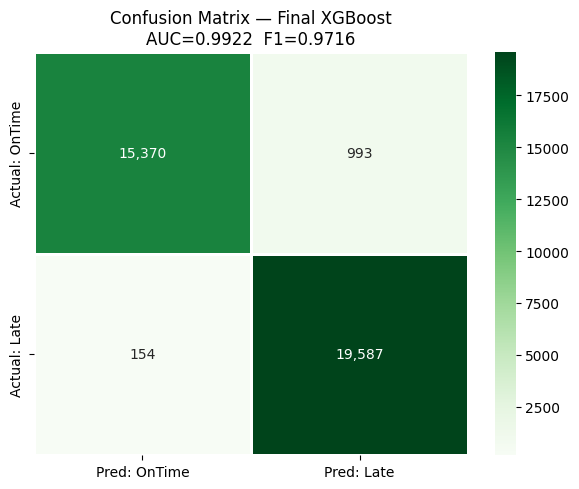

TN=15,370  FP=993  FN=154  TP=19,587
Missed real disruptions (FN): 154  (0.4%)
False alarms           (FP): 993  (2.8%)


In [9]:
# What: plots a 2x2 grid showing correct vs wrong predictions
# Why: AUC alone doesn't tell you WHERE the model fails
#      confusion matrix shows:
#      - True Positives  (predicted Late, actually Late)   → correct
#      - True Negatives  (predicted OnTime, actually OnTime) → correct
#      - False Positives (predicted Late, actually OnTime) → false alarm
#      - False Negatives (predicted OnTime, actually Late) → MISSED disruption
#      For your project, False Negatives are worst - missing real disruptions
# Expected output: a colored heatmap with 4 numbers

cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt=",", cmap="Greens",
    xticklabels=["Pred: OnTime", "Pred: Late"],
    yticklabels=["Actual: OnTime", "Actual: Late"],
    linewidths=1, ax=ax
)
ax.set_title(f"Confusion Matrix — Final XGBoost\nAUC={auc_final:.4f}  F1={f1_final:.4f}")
plt.tight_layout()
plt.savefig("confusion_matrix_scratch.png", dpi=130)
plt.show()

total = tn + fp + fn + tp
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"Missed real disruptions (FN): {fn:,}  ({fn/total*100:.1f}%)")
print(f"False alarms           (FP): {fp:,}  ({fp/total*100:.1f}%)")

Computing SHAP values (this takes ~2 min)...


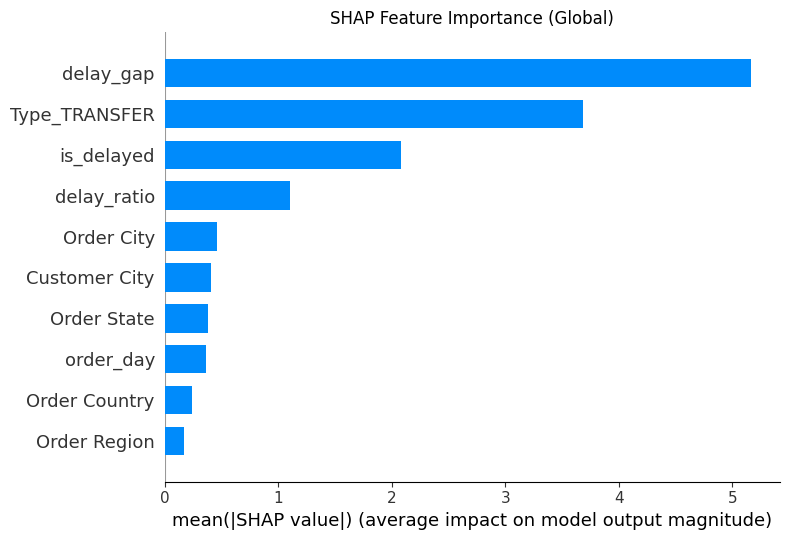

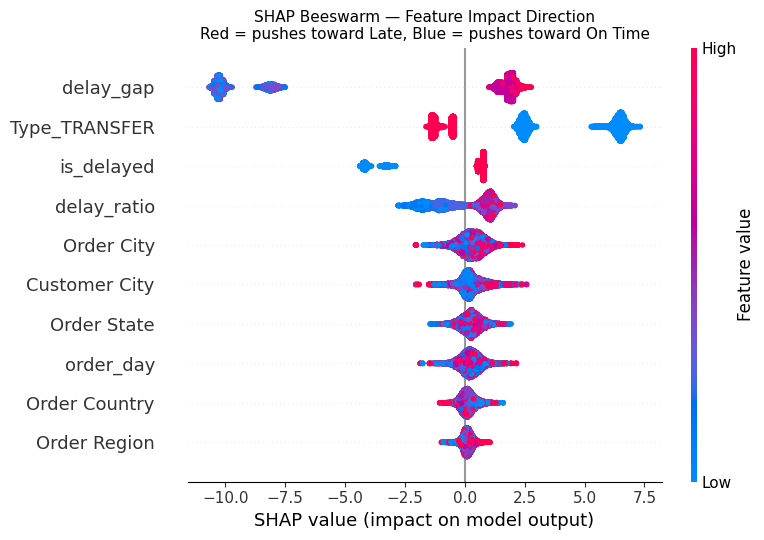

✓ SHAP charts saved

How to read the beeswarm:
  Each dot = one order in the test set
  Red dot  = that feature had a HIGH value for that order
  Blue dot = that feature had a LOW value
  Right    = pushed prediction toward LATE (1)
  Left     = pushed prediction toward ON TIME (0)


In [10]:
# What: calculates SHAP values - how much each feature contributed
#       to each individual prediction
# Why: AUC tells you the model is good but not WHY
#      SHAP tells you for EACH shipment:
#      "delay_gap of +2 days pushed this 0.42 toward LATE"
#      "Shipping Mode = Standard pulled this 0.18 toward LATE"
#      This is essential for Phase 3 route optimization -
#      you need to know the REASON to suggest a FIX
# Expected output: 2 charts - bar chart + beeswarm plot (~2 min)

print("Computing SHAP values (this takes ~2 min)...")

import xgboost as xgb

# Extract the booster and patch the base_score before passing to SHAP
booster = final_model.get_booster()
# booster.attrs()  # just to confirm

explainer = shap.TreeExplainer(final_model) # pass booster directly instead of final_model
shap_values = explainer.shap_values(X_test)

# Chart 1: Global importance - which features matter most overall
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  show=False, max_display=10)
plt.title("SHAP Feature Importance (Global)", fontsize=12)
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=130)
plt.show()

# Chart 2: Beeswarm - direction of impact per feature
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, show=False, max_display=10)
plt.title("SHAP Beeswarm — Feature Impact Direction\n"
          "Red = pushes toward Late, Blue = pushes toward On Time", fontsize=11)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=130)
plt.show()

print("✓ SHAP charts saved")
print("\nHow to read the beeswarm:")
print("  Each dot = one order in the test set")
print("  Red dot  = that feature had a HIGH value for that order")
print("  Blue dot = that feature had a LOW value")
print("  Right    = pushed prediction toward LATE (1)")
print("  Left     = pushed prediction toward ON TIME (0)")

In [13]:
print(automl_preds.columns)

Index(['Late_delivery_risk', 'delay_gap', 'Days for shipping (real)',
       'Days for shipment (scheduled)', 'predicted_class', 'prob_0', 'prob_1',
       'correct'],
      dtype='object')


HEAD-TO-HEAD: AutoML vs Scratch Model
  Metric                     AutoML      Scratch
  --------------------------------------------
  AUC-ROC                    0.9926       0.9922
  F1 Score                   0.9685       0.9716

  Orders where models DISAGREE: 426
  (1.2% of all test orders)
  → These are the borderline, uncertain shipments


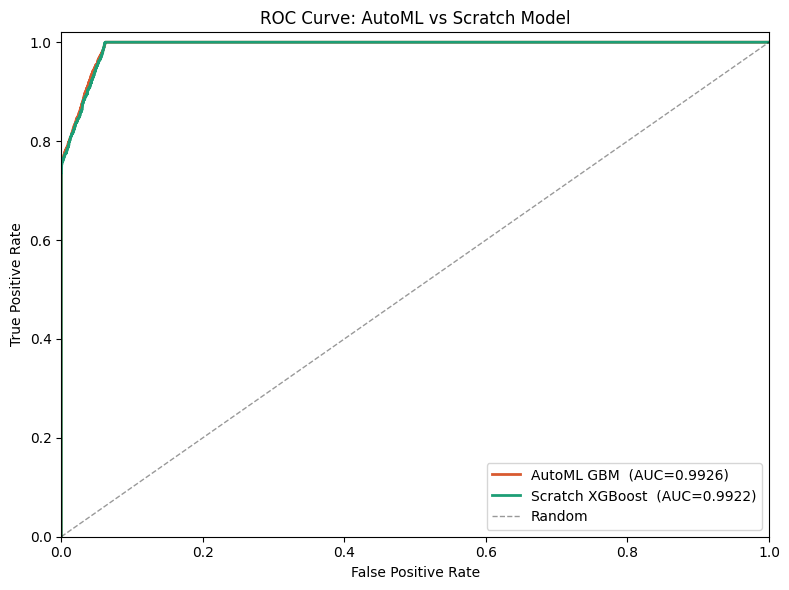

In [15]:
# What: loads AutoML predictions and compares side by side
# Why: comparing row by row reveals which orders both models agree on
#      (easy cases) vs disagree on (hard, borderline cases)
#      disagreements = the most uncertain shipments = highest risk for Phase 3
# Expected output: metrics table, ROC curves on same chart, disagreement count

automl_preds = pd.read_csv("automl_test_predictions.csv")

# Build comparison dataframe
compare_df = pd.DataFrame({
    "actual"          : y_test.values,
    "automl_class"    : automl_preds["predicted_class"].values,
    "scratch_class"   : y_pred_final,
    "automl_prob_late": automl_preds["prob_1"].values,
    "scratch_prob_late": y_prob_final,
})

automl_auc  = roc_auc_score(compare_df["actual"], compare_df["automl_prob_late"])
scratch_auc = roc_auc_score(compare_df["actual"], compare_df["scratch_prob_late"])
automl_f1   = f1_score(compare_df["actual"], compare_df["automl_class"].astype(int))
scratch_f1  = f1_score(compare_df["actual"], compare_df["scratch_class"])

print("=" * 55)
print("HEAD-TO-HEAD: AutoML vs Scratch Model")
print("=" * 55)
print(f"  {'Metric':<20} {'AutoML':>12} {'Scratch':>12}")
print(f"  {'-'*44}")
print(f"  {'AUC-ROC':<20} {automl_auc:>12.4f} {scratch_auc:>12.4f}")
print(f"  {'F1 Score':<20} {automl_f1:>12.4f} {scratch_f1:>12.4f}")

# Find disagreements
disagree = (compare_df["automl_class"].astype(int) !=
            compare_df["scratch_class"].astype(int))
print(f"\n  Orders where models DISAGREE: {disagree.sum():,}")
print(f"  ({disagree.mean()*100:.1f}% of all test orders)")
print(f"  → These are the borderline, uncertain shipments")

# Dual ROC curve
fig, ax = plt.subplots(figsize=(8, 6))
for name, probs, color in [
    ("AutoML GBM",    compare_df["automl_prob_late"],  "#D85A30"),
    ("Scratch XGBoost", compare_df["scratch_prob_late"], "#1D9E75"),
]:
    fpr, tpr, _ = roc_curve(compare_df["actual"], probs)
    auc = roc_auc_score(compare_df["actual"], probs)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC={auc:.4f})")

ax.plot([0,1],[0,1],"k--", lw=1, alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: AutoML vs Scratch Model")
ax.legend(loc="lower right")
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=130)
plt.show()

In [12]:
# What: saves the final model as a pickle file, saves predictions and SHAP values
# Why: Phase 3 needs to load this model to score new shipments in real time
#      The pickle file contains everything - you never retrain from scratch again
#      SHAP values CSV lets Phase 3 explain each individual disruption flag
# Expected output: 3 files saved, confirmation printed

import pickle

# 1. Save the trained model
with open("model_scratch_xgb.pkl", "wb") as f:
    pickle.dump(final_model, f)
print("✓ model_scratch_xgb.pkl saved")

# 2. Save test predictions with probabilities
results = test_df[["Late_delivery_risk", "delay_gap",
                   "Days for shipping (real)",
                   "Days for shipment (scheduled)"]].copy()
results["scratch_pred_class"] = y_pred_final
results["scratch_prob_late"]  = y_prob_final.round(4)
results["correct"]            = (results["Late_delivery_risk"] ==
                                  results["scratch_pred_class"]).astype(int)
results.to_csv("scratch_test_predictions.csv", index=False)
print("✓ scratch_test_predictions.csv saved")

# 3. Save SHAP values
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df.to_csv("shap_values_scratch.csv", index=False)
print("✓ shap_values_scratch.csv saved")

# Final summary
print("\n" + "=" * 55)
print("PHASE 2 COMPLETE")
print("=" * 55)
print(f"  AutoML AUC    : 0.9926")
print(f"  Scratch AUC   : {auc_final:.4f}")
print(f"  Difference    : {abs(0.9926 - auc_final):.4f}")
print(f"  Top feature   : delay_gap (68.7% importance)")
print(f"  Features used : {TOP_N} (out of 45 available)")
print(f"\n  Files ready for Phase 3:")
print(f"    model_scratch_xgb.pkl        ← real-time scoring")
print(f"    scratch_test_predictions.csv ← predictions with probs")
print(f"    shap_values_scratch.csv      ← explanations")
print(f"\n  Next → Phase 3: Anomaly detection + route optimization")

✓ model_scratch_xgb.pkl saved
✓ scratch_test_predictions.csv saved
✓ shap_values_scratch.csv saved

PHASE 2 COMPLETE
  AutoML AUC    : 0.9926
  Scratch AUC   : 0.9922
  Difference    : 0.0004
  Top feature   : delay_gap (68.7% importance)
  Features used : 10 (out of 45 available)

  Files ready for Phase 3:
    model_scratch_xgb.pkl        ← real-time scoring
    scratch_test_predictions.csv ← predictions with probs
    shap_values_scratch.csv      ← explanations

  Next → Phase 3: Anomaly detection + route optimization
